# 02 — Crime by West Mercia district

Goal: extract district names, check the extraction is trustworthy (as we
did for London — don't assume it just works), then aggregate and visualize.

In [1]:
import sys
sys.path.append("../../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from load_data import load_force_data
from clean import clean_crime_data, add_area_column, WEST_MERCIA_DISTRICTS

sns.set_theme(style="whitegrid")

wm = load_force_data("west-mercia")
wm = clean_crime_data(wm)

# add_area_column is the same rsplit logic as London's add_borough_column,
# just writing to a column called "District" instead of "Borough" --
# see src/clean.py. Rows with no LSOA name (the "No Location" rows from
# notebook 01) come out with a missing District, which is correct: there's
# nothing to assign them to.
wm = add_area_column(wm, column_name="District")
wm["District"].nunique()

40

### Finding: 40 "districts", not 9

West Mercia covers 9 real local authorities. Checking which rows fall
outside that set (excluding the rows with no District at all first):

In [2]:
has_district = wm["District"].notna()
outside = has_district & ~wm["District"].isin(WEST_MERCIA_DISTRICTS)

print(f"outside real districts: {outside.sum()} of {has_district.sum()} "
      f"geolocated rows ({outside.sum() / has_district.sum():.2%})")
wm.loc[outside, "Crime type"].value_counts()

outside real districts: 3224 of 108400 geolocated rows (2.97%)


Crime type
Anti-social behaviour           2956
Violence and sexual offences     116
Criminal damage and arson         37
Other theft                       26
Burglary                          19
Vehicle crime                     19
Public order                      16
Shoplifting                       13
Other crime                        8
Drugs                              7
Possession of weapons              3
Robbery                            3
Bicycle theft                      1
Name: count, dtype: int64

**~3% of geolocated rows sit outside the 9 real districts** — and unlike
London (where the equivalent 0.53% was almost entirely "Violence and
sexual offences", i.e. deliberate sensitive-crime anonymisation), here it's
**92% Anti-social behaviour**. A likely explanation: West Mercia genuinely
borders Wales (Powys, Ceredigion — the top two districts outside our set),
so this looks more like ordinary coordinate-snapping across a real,
physical border than deliberate anonymisation. Since we can't be certain
of the exact mechanism, we treat it descriptively rather than assert a
cause — either way, these rows get excluded from district-level analysis
the same way as London's equivalent.

In [3]:
wmd = wm[wm["District"].isin(WEST_MERCIA_DISTRICTS)]
print(f"kept {len(wmd):,} of {len(wm):,} rows ({len(wmd) / len(wm):.2%})")

kept 105,176 of 110,499 rows (95.18%)


## Chart 1 — total crimes by district

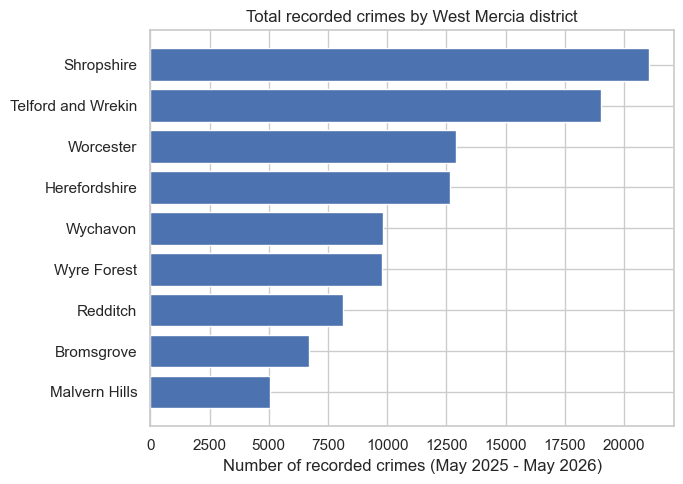

In [4]:
district_counts = wmd.groupby("District").size().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(district_counts.index, district_counts.values, color="#4C72B0")
ax.set_xlabel("Number of recorded crimes (May 2025 - May 2026)")
ax.set_title("Total recorded crimes by West Mercia district")
fig.tight_layout()

Shropshire and Telford and Wrekin lead by raw count — but they're also the
two largest districts by population. Same caveat as London's notebook 02:
raw counts conflate "more crime" with "more people", so this isn't the
final word (per-capita rates come in notebook 03).

## Chart 2 — monthly trend across West Mercia

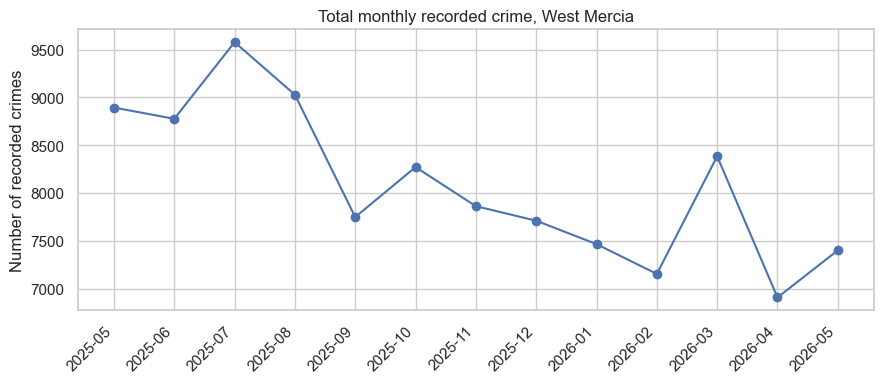

In [5]:
monthly_counts = wmd.groupby("Month").size().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly_counts.index, monthly_counts.values, marker="o", color="#4C72B0")
ax.set_ylabel("Number of recorded crimes")
ax.set_title("Total monthly recorded crime, West Mercia")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()

More volatile month-to-month than London's smoother curve (notebook 02) —
expected, since West Mercia's monthly totals are ~9x smaller, so the same
size of random fluctuation is a much bigger fraction of the total.

## Chart 3 — crime type by district

Same trimming rationale as London's notebook 02: with 14 crime types most
columns were too thin to read anything from. Keeping the **top 6 crime
types by total count** leaves out ~15% of all recorded crime (less than
London's ~24%, since West Mercia's distribution is a bit more concentrated
in its top categories) — spread thinly enough across the remaining 8
categories that none of them had much visual presence in a 14-column
heatmap anyway.

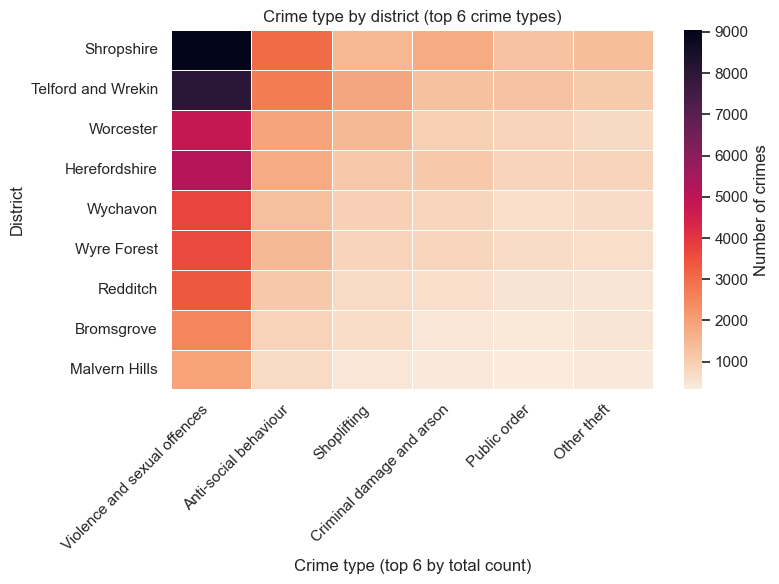

In [6]:
crime_type_order = wmd["Crime type"].value_counts().index
top_crime_types = crime_type_order[:6]  # sorted descending, so this is "top 6"

pivot = pd.crosstab(wmd["District"], wmd["Crime type"])
pivot = pivot.loc[district_counts.sort_values(ascending=False).index]
pivot = pivot[top_crime_types]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    cmap="rocket_r",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Number of crimes"},
    ax=ax,
)
ax.set_xlabel("Crime type (top 6 by total count)")
ax.set_ylabel("District")
ax.set_title("Crime type by district (top 6 crime types)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()

Same dominant categories as London (Violence and sexual offences, then
Anti-social behaviour) — the *mix* looks broadly similar across districts
here, without an obvious standout profile the way some London boroughs had.
Worth another look once we bring in per-capita rates.